In [3]:
import numpy as np

In [12]:
data = np.load('./data4/sentinel-2-l2a/cube_3.npz')

In [13]:
print(data.files)

['pixels']


In [14]:
a = data['pixels']
print(a.shape)

(128, 4, 256, 256)


In [15]:
# Take the first image
img = a[0]   # shape (3, 256, 256)

# Rearrange to (256, 256, 3) for visualization
img = np.transpose(img, (1, 2, 0))

print(img.shape)   # (256, 256, 3)
print(img.min(), img.max())  # value range


(256, 256, 4)
326 10984


In [20]:
import numpy as np

def normalize_to_uint8(arr):
    """Normalize array to 0–255 and convert to uint8."""
    arr_min, arr_max = arr.min(), arr.max()
    scaled = (arr - arr_min) / (arr_max - arr_min) * 255
    return scaled.astype(np.uint8)


In [21]:
import matplotlib.pyplot as plt

# Suppose you have 3 bands stacked: Red, Green, Blue
red = stacked_chip[2]   # B04
green = stacked_chip[1] # B03
blue = stacked_chip[0]  # B02

rgb = np.dstack([
    normalize_to_uint8(red),
    normalize_to_uint8(green),
    normalize_to_uint8(blue)
])

plt.imshow(rgb)
plt.axis("off")
plt.show()


NameError: name 'stacked_chip' is not defined

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [326..10984].


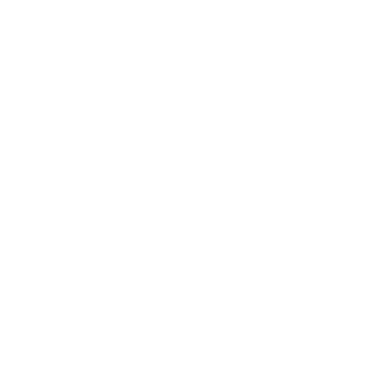

In [16]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.show()


In [17]:

# Take the first image
img = a[0]   # shape (3, 256, 256)

# Separate channels
red   = img[0]   # channel 0
green = img[1]   # channel 1
blue  = img[2]   # channel 2

print(red.shape, green.shape, blue.shape)  # each (256, 256)

(256, 256) (256, 256) (256, 256)


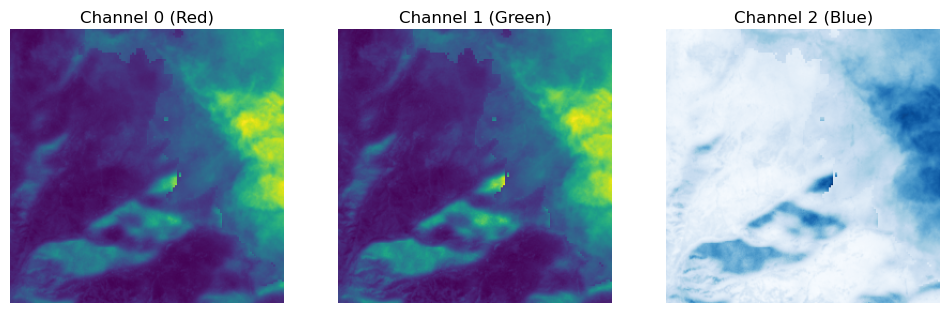

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(red)
axs[0].set_title("Channel 0 (Red)")
axs[0].axis("off")

axs[1].imshow(green)
axs[1].set_title("Channel 1 (Green)")
axs[1].axis("off")

axs[2].imshow(blue, cmap='Blues')
axs[2].set_title("Channel 2 (Blue)")
axs[2].axis("off")

plt.show()


In [19]:
from pystac_client import Client

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = catalog.search(collections=["sentinel-2-l2a"], max_items=1)
item = next(search.get_items())
print(item.id)
print(item.assets.keys())


/opt/anaconda3/envs/claymodel/lib/python3.11/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


S2B_MSIL2A_20251205T022959_R046_T54VVP_20251205T040026
dict_keys(['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview'])
